In [13]:
import os

print("1. Current working directory:", os.getcwd())

if os.path.exists('data/raw'):
    print("2. Contents of data/raw/:", os.listdir('data/raw/'))
else:
    print("2. The folder 'data/raw' does NOT exist.")

1. Current working directory: C:\Users\User\Documents
2. The folder 'data/raw' does NOT exist.


In [7]:
import os

print(os.getcwd())

C:\Users\User\Documents


In [8]:
print(os.listdir())

['.ipynb_checkpoints', 'archive.zip', 'Dadroit JSON Generator', 'Exercise 1.m', 'IT25101560.m', 'IT25101560Lab3.m', 'My Music', 'My Pictures', 'My Videos', 'Rules mta.docx', 'Testing', 'tf_env', 'Training', 'Untitled.ipynb', 'Untitled1.ipynb']


In [14]:
TRAINING_PATH = r"C:\Users\User\Documents\Training"

In [15]:
import os

TRAINING_PATH = r"C:\Users\User\Documents\Training"

print("Training folder exists:", os.path.exists(TRAINING_PATH))
print("Folders found:", os.listdir(TRAINING_PATH))

Training folder exists: True
Folders found: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelBinarizer
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


In [17]:
# Data Cleaning & Outlier Removal

# Define paths and parameters
DATA_DIR = r"C:\Users\User\Documents\Training"
CATEGORIES = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
IMG_SIZE = 224

data = []
labels = []
corrupted_files = []
outlier_shapes = []

print("Starting data loading and cleaning...")

for category in CATEGORIES:
    folder_path = os.path.join(DATA_DIR, category)
    
    if not os.path.exists(folder_path):
        print(f"Warning: Path {folder_path} does not exist. Check your folder structure.")
        continue
        
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        
        # 1. Handling missing/corrupted data
        # Check if image is readable
        img_array = cv2.imread(img_path, cv2.IMREAD_COLOR)
        
        if img_array is None:
            corrupted_files.append(img_path)
            continue
            
        # 2. Outlier Removal
        # Remove completely blank images or images with abnormal size
        if np.sum(img_array) == 0 or img_array.shape[0] < 50:
            outlier_shapes.append(img_path)
            continue
        
        # Resize to exactly 224x224 for VGG16
        resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
        
        # Convert BGR (OpenCV default) to RGB
        resized_array = cv2.cvtColor(resized_array, cv2.COLOR_BGR2RGB)
        
        data.append(resized_array)
        labels.append(category)

print(f"Successfully loaded {len(data)} valid images.")
print(f"Missing/Corrupted Files Removed: {len(corrupted_files)}")
print(f"Outliers (Blank/Tiny) Removed: {len(outlier_shapes)}")

Starting data loading and cleaning...
Successfully loaded 2870 valid images.
Missing/Corrupted Files Removed: 0
Outliers (Blank/Tiny) Removed: 0


In [1]:
import os
import cv2
import numpy as np
from sklearn.preprocessing import LabelBinarizer
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

# Dataset path
DATA_DIR = r"C:\Users\User\Documents\Training"

CATEGORIES = [
    "glioma_tumor",
    "meningioma_tumor",
    "no_tumor",
    "pituitary_tumor"
]

IMG_SIZE = 224

# Only load a small number of images for EDA/PCA
MAX_IMAGES_PER_CLASS = 100

data = []
labels = []
corrupted_files = []
outlier_shapes = []

print("Starting data loading...")

for category in CATEGORIES:

    folder_path = os.path.join(DATA_DIR, category)

    if not os.path.exists(folder_path):
        print("Missing:", folder_path)
        continue

    image_names = os.listdir(folder_path)

    # Limit images loaded into RAM
    image_names = image_names[:MAX_IMAGES_PER_CLASS]

    for img_name in image_names:

        img_path = os.path.join(folder_path, img_name)

        img_array = cv2.imread(img_path, cv2.IMREAD_COLOR)

        if img_array is None:
            corrupted_files.append(img_path)
            continue

        # Remove blank/tiny images
        if np.sum(img_array) == 0 or img_array.shape[0] < 50:
            outlier_shapes.append(img_path)
            continue

        # Resize
        resized_array = cv2.resize(
            img_array,
            (IMG_SIZE, IMG_SIZE)
        )

        # BGR → RGB
        resized_array = cv2.cvtColor(
            resized_array,
            cv2.COLOR_BGR2RGB
        )

        # Normalize immediately
        resized_array = resized_array.astype(np.float32) / 255.0

        data.append(resized_array)
        labels.append(category)

print("Successfully loaded:", len(data), "images")
print("Corrupted files:", len(corrupted_files))
print("Outliers:", len(outlier_shapes))

Starting data loading...
Successfully loaded: 400 images
Corrupted files: 0
Outliers: 0


In [2]:
# Convert to NumPy array
X = np.asarray(data, dtype=np.float32)

print("X shape:", X.shape)
print("X memory:", X.nbytes / (1024**2), "MB")


# One-Hot Encoding
label_binarizer = LabelBinarizer()
y_encoded = label_binarizer.fit_transform(labels)

# Integer labels
y_integers = np.argmax(y_encoded, axis=1)

# Class weights
classes = np.unique(y_integers)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_integers
)

class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)


# PCA
print("Applying PCA...")

X_flattened = X.reshape(len(X), -1)

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_flattened)

print("PCA transformation complete.")
print("PCA shape:", X_pca.shape)

X shape: (400, 224, 224, 3)
X memory: 229.6875 MB
Class Weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0), np.int64(3): np.float64(1.0)}
Applying PCA...
PCA transformation complete.
PCA shape: (400, 2)


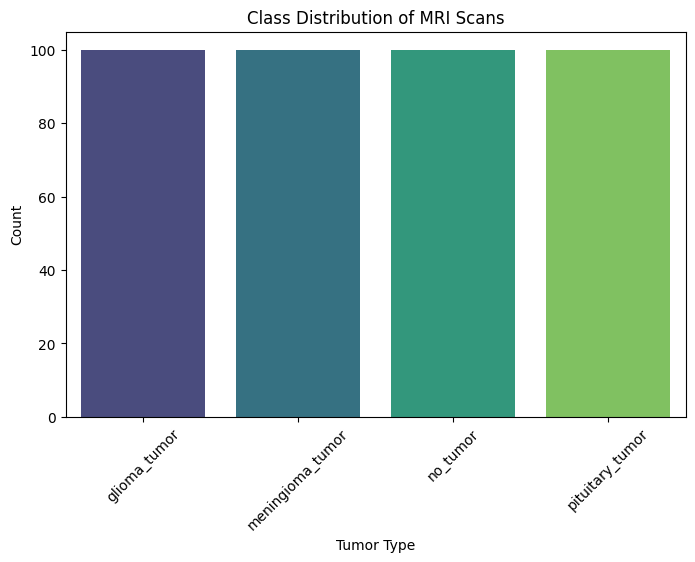

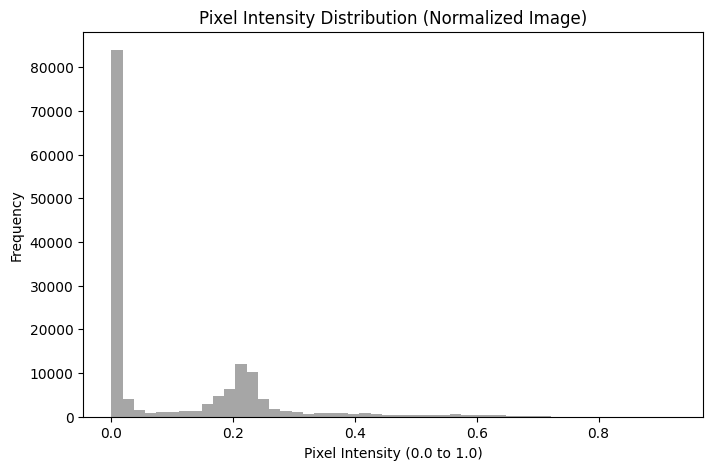

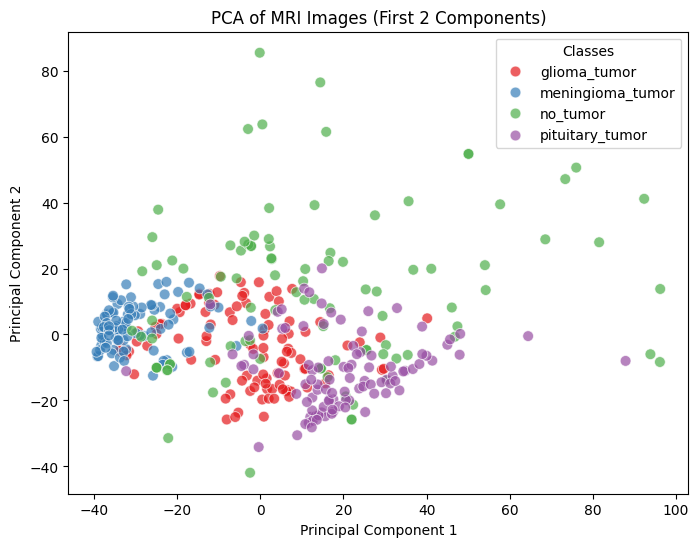

In [4]:
#EDA Visualizations

import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("results/eda_visualizations", exist_ok=True)


# Visualization 1: Class Distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    x=labels,
    hue=labels,
    palette="viridis",
    legend=False
)

plt.title("Class Distribution of MRI Scans")
plt.xlabel("Tumor Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.savefig(
    "results/eda_visualizations/class_distribution.png",
    bbox_inches="tight"
)

plt.show()


# Visualization 2: Pixel Intensity Distribution
plt.figure(figsize=(8, 5))

plt.hist(
    X[0].ravel(),
    bins=50,
    color="gray",
    alpha=0.7
)

plt.title("Pixel Intensity Distribution (Normalized Image)")
plt.xlabel("Pixel Intensity (0.0 to 1.0)")
plt.ylabel("Frequency")

plt.savefig(
    "results/eda_visualizations/pixel_intensity.png",
    bbox_inches="tight"
)

plt.show()


# Visualization 3: PCA Scatter Plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels,
    palette="Set1",
    s=60,
    alpha=0.7
)

plt.title("PCA of MRI Images (First 2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Classes")

plt.savefig(
    "results/eda_visualizations/pca_scatter.png",
    bbox_inches="tight"
)

plt.show()

In [7]:
#VGG16 Data Augmentation Pipeline

from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32

# Apply Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

# Training data - 80%
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

# Validation data - 20%
val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.


In [9]:
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [10]:
# Load pre-trained VGG16 feature extractor
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Phase 1: Freeze all base layers
base_model.trainable = False

# Build custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

# 4 classes
outputs = Dense(4, activation="softmax")(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs,
    name="VGG16_Phase1"
)

# Compile using Adam
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 496s 8us/step


Model: "VGG16_Phase1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         131,3

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

os.makedirs("results/outputs", exist_ok=True)

callbacks_phase1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        "results/outputs/best_vgg16_phase1.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Starting Phase 1 Training (Head Only)...")

history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_phase1
)

Starting Phase 1 Training (Head Only)...
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3889 - loss: 1.3156
Epoch 1: val_loss improved from None to 1.11654, saving model to results/outputs/best_vgg16_phase1.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 794s 11s/step - accuracy: 0.4502 - loss: 1.2110 - val_accuracy: 0.4974 - val_loss: 1.1165
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6229 - loss: 0.9836
Epoch 2: val_loss improved from 1.11654 to 0.98779, saving model to results/outputs/best_vgg16_phase1.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 674s 9s/step - accuracy: 0.6334 - loss: 0.9449 - val_accuracy: 0.5445 - val_loss: 0.9878
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6897 - loss: 0.8349
Epoch 3: val_loss improved from 0.98779 to 0.90992, saving model to results/outputs/best_vgg16_phase1.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 665s 9s/step - accuracy: 0.7057 - loss: 0.8017 - val_accuracy: 0.5951 - val_loss: 0.9099
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s